# Interrupted Time Series (ITS) Counterfactual for a Global Price Change

This notebook demonstrates a complete, reproducible workflow to estimate the impact of a **global price intervention** on **churn** using **single-series Interrupted Time Series (ITS)**.

## What this notebook shows

When a price increase is applied to **everyone at once**, there is no untreated control group. A classic A/B test is not possible, but the business still needs an estimate of:

- whether churn changed after the price intervention
- how large the impact was
- whether the observed change is distinguishable from normal trend, seasonality, and noise

This notebook shows one way to handle that problem by building a **model-based counterfactual** from the pre-intervention period and comparing it with what actually happened after the intervention.

**Important:** All data in this notebook is **synthetic** and generated solely for demonstration purposes.


## When this approach is appropriate

This type of single-series ITS design is most useful when:

- the intervention affects the full population at once
- no randomized control group exists
- the intervention date is known
- you have enough pre-period history to model baseline dynamics

## Key assumptions

A single-series ITS design relies on a few important assumptions:

1. **Pre-period dynamics are informative** about the no-intervention path.
2. **No other major concurrent intervention** fully explains the post-period shift.
3. **Trend and seasonality are modeled reasonably well**.
4. **Residual autocorrelation is handled appropriately** in inference.

This does **not** make the design as strong as a clean randomized experiment. It does make it far more credible than a naive before-and-after comparison.


In [1]:
# Core stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

np.random.seed(7)

def make_weekly_calendar(start="2023-01-07", periods=156, freq="W-SAT"):
    idx = pd.date_range(start=start, periods=periods, freq=freq)
    df = pd.DataFrame({"week": idx})
    df["t"] = np.arange(len(df))
    df["month"] = df["week"].dt.month.astype("category")
    return df

def ar1_noise(n, phi=0.6, sigma=0.0025):
    eps = np.zeros(n)
    eta = np.random.normal(0, sigma, size=n)
    for i in range(1, n):
        eps[i] = phi * eps[i - 1] + eta[i]
    return eps


## 1) Create a realistic synthetic dataset

We simulate a weekly churn series with:

- a baseline level
- a mild time trend
- month seasonality
- a shared marketing / traffic covariate
- autocorrelated noise
- a price intervention that creates both:
  - an immediate level shift
  - a post-intervention slope change

This mirrors a common business setting where a global price change affects the entire user base.


In [2]:
df = make_weekly_calendar(periods=156)  # about 3 years of weekly data

# Synthetic intervention date (global price change)
intervention_week = pd.Timestamp("2025-01-04")

# ITS features
df["post"] = (df["week"] >= intervention_week).astype(int)
t0 = df.loc[df["week"] >= intervention_week, "t"].min()
df["t_post"] = np.where(df["post"].eq(1), df["t"] - t0, 0)

# Exogenous covariate (shared driver): marketing / traffic index
df["mkt_index"] = 100 + 3 * np.sin(2 * np.pi * df["t"] / 26) + 0.6 * np.random.normal(size=len(df))

# Month seasonality effects on churn
month_effect = {
    1:  0.0020, 2:  0.0015, 3:  0.0005, 4: -0.0005,
    5: -0.0010, 6: -0.0012, 7: -0.0006, 8: -0.0003,
    9:  0.0004, 10: 0.0010, 11: 0.0016, 12: 0.0022,
}

# Synthetic data-generating process
base_level = 0.080
base_trend = 0.00002
beta_mkt = -0.00035

level_jump = 0.006
slope_change = 0.00004

df["churn"] = (
    base_level
    + base_trend * df["t"]
    + df["month"].astype(int).map(month_effect)
    + beta_mkt * (df["mkt_index"] - df["mkt_index"].mean())
    + level_jump * df["post"]
    + slope_change * df["t_post"]
    + ar1_noise(len(df), phi=0.60, sigma=0.0025)
).clip(0.0, 1.0)

df.head()


,week,t,month,post,t_post,mkt_index,churn
0,2023-01-07,0,1,0,0,101.014315,0.081637
1,2023-01-14,1,1,0,0,100.438385,0.083755
2,2023-01-21,2,1,0,0,101.413862,0.085691
3,2023-01-28,3,1,0,0,102.233878,0.086214
4,2023-02-04,4,2,0,0,101.995598,0.081516


### Quick visual sanity check

We first look at the churn time series itself before fitting any model.


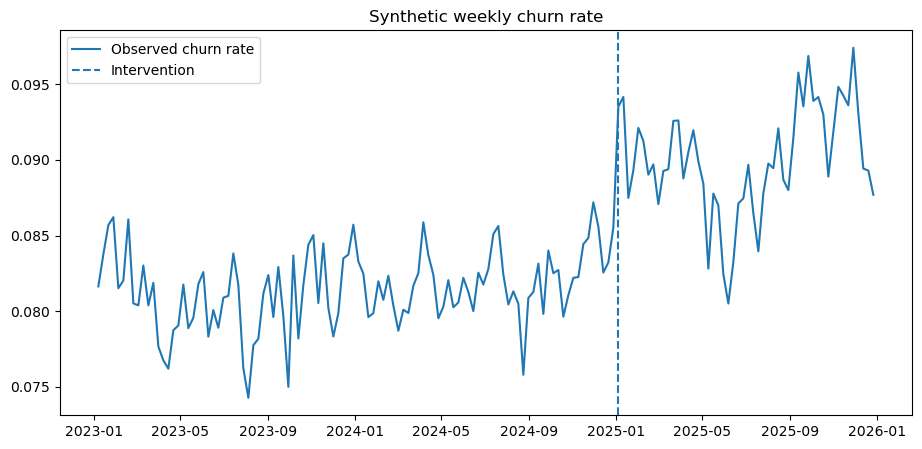

In [3]:
fig = plt.figure(figsize=(11, 5))
plt.plot(df["week"], df["churn"], label="Observed churn rate")
plt.axvline(intervention_week, linestyle="--", label="Intervention")
plt.title("Synthetic weekly churn rate")
plt.legend()
plt.show()


### What this chart shows

This plot shows the full churn series around the intervention date.

- Before the intervention, churn follows a baseline trend plus seasonality and noise.
- After the intervention, the observed series may shift in **level** and/or **slope**.
- The job of ITS is to estimate what the post-period would have looked like **without** the intervention.


## 2) Fit the Interrupted Time Series model

We fit a segmented regression with:

- `t`: baseline trend
- `post`: immediate level change at the intervention
- `t_post`: slope change after the intervention
- `C(month)`: month seasonality
- `mkt_index`: a contemporaneous business driver included as a covariate

We then use **HAC / Newey-West** standard errors so inference remains more robust to autocorrelation.


In [4]:
# Outcome variable
df["y"] = df["churn"]

# Fit OLS segmented regression
ols = smf.ols("y ~ t + post + t_post + C(month) + mkt_index", data=df).fit()

# HAC / Newey-West robust standard errors
hac_lags = 6
ols_hac = smf.ols("y ~ t + post + t_post + C(month) + mkt_index", data=df).fit(
    cov_type="HAC",
    cov_kwds={"maxlags": hac_lags}
)

print("Coefficient estimates:")
print(ols_hac.params[["t", "post", "t_post", "mkt_index"]])
print()
print("HAC robust standard errors:")
print(ols_hac.bse[["t", "post", "t_post", "mkt_index"]])


Coefficient estimates:
t            0.000022
post         0.005969
t_post       0.000035
mkt_index   -0.000530
dtype: float64

HAC robust standard errors:
t            0.000012
post         0.001513
t_post       0.000035
mkt_index    0.000217
dtype: float64


## 3) Construct the counterfactual

To estimate the no-intervention path, we create a counterfactual world where:

- `post = 0`
- `t_post = 0`

Everything else, including calendar time, seasonality, and the contemporaneous covariate, continues as observed.

The estimated effect at each time point is:

\[
\text{effect}_t = \hat y^{obs}_t - \hat y^{cf}_t
\]


In [5]:
df_pred = df.copy()

# Predictions under the observed world
df_pred["y_hat_obs"] = ols_hac.predict(df_pred)

# Counterfactual world: intervention switched off
df_cf = df_pred.copy()
df_cf["post"] = 0
df_cf["t_post"] = 0
df_pred["y_hat_cf"] = ols_hac.predict(df_cf)

# Estimated incremental effect
df_pred["effect"] = df_pred["y_hat_obs"] - df_pred["y_hat_cf"]


### Plot: observed vs counterfactual

This is the key figure: it shows the modeled no-intervention path and the observed churn series on the same chart.


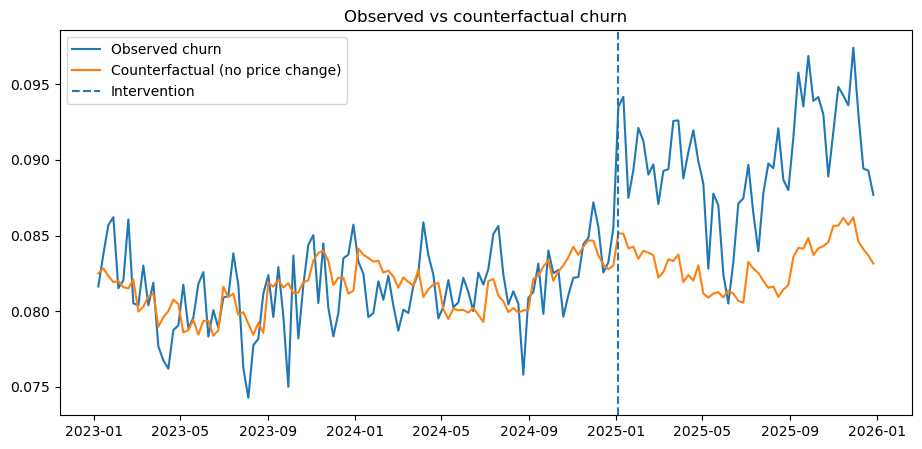

In [6]:
fig = plt.figure(figsize=(11, 5))
plt.plot(df_pred["week"], df_pred["y"], label="Observed churn")
plt.plot(df_pred["week"], df_pred["y_hat_cf"], label="Counterfactual (no price change)")
plt.axvline(intervention_week, linestyle="--", label="Intervention")
plt.title("Observed vs counterfactual churn")
plt.legend()
plt.show()


### What this chart shows

The counterfactual line represents what the model predicts churn would have been **if the price change had not occurred**, under the ITS assumptions.

The vertical distance between the observed line and the counterfactual line in the post period is the estimated **incremental impact** of the intervention.


### Plot: intervention, counterfactual, and highlighted causal effect

This view makes the causal effect visually explicit by shading the post-intervention gap between the observed series and the counterfactual.


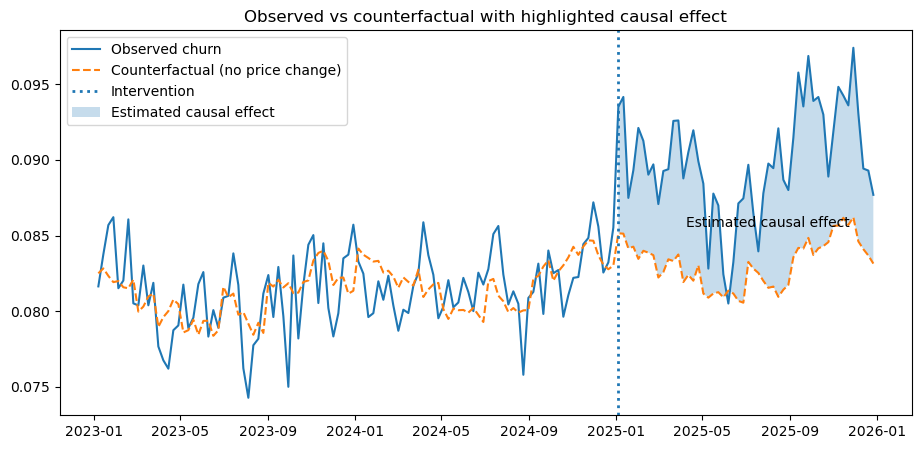

In [7]:
post_mask = df_pred["week"] >= intervention_week

fig = plt.figure(figsize=(11, 5))
plt.plot(df_pred["week"], df_pred["y"], label="Observed churn")
plt.plot(df_pred["week"], df_pred["y_hat_cf"], linestyle="--", label="Counterfactual (no price change)")
plt.axvline(intervention_week, linestyle=":", linewidth=2, label="Intervention")

plt.fill_between(
    df_pred.loc[post_mask, "week"],
    df_pred.loc[post_mask, "y"],
    df_pred.loc[post_mask, "y_hat_cf"],
    alpha=0.25,
    label="Estimated causal effect"
)

# Annotate one representative post-period point
ann_idx = df_pred.index[post_mask][min(8, post_mask.sum()-1)]
x_annot = df_pred.loc[ann_idx, "week"]
y_obs = df_pred.loc[ann_idx, "y"]
y_cf = df_pred.loc[ann_idx, "y_hat_cf"]
y_mid = (y_obs + y_cf) / 2

plt.annotate(
    "Estimated causal effect",
    xy=(x_annot, y_mid),
    xytext=(20, 10),
    textcoords="offset points"
)

plt.title("Observed vs counterfactual with highlighted causal effect")
plt.legend()
plt.show()


### What this chart shows

- The **dashed line** is the estimated counterfactual: what churn would likely have been without the intervention.
- The **vertical line** marks the intervention date.
- The **shaded area** is the estimated causal effect in the post period: the gap between the observed series and the no-intervention path.

This is often the most intuitive way to explain the result to a nontechnical audience because it makes the core causal comparison visible in a single figure.


## 4) Residual diagnostics

Before trusting the inference too much, we should examine residual autocorrelation.


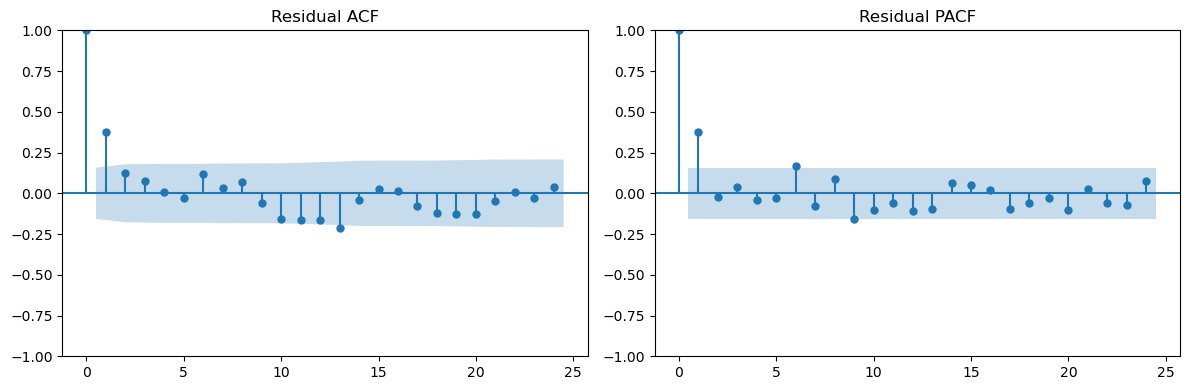

In [8]:
resid = ols.resid

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(resid, ax=axes[0], lags=24)
plot_pacf(resid, ax=axes[1], lags=24, method="ywm")
axes[0].set_title("Residual ACF")
axes[1].set_title("Residual PACF")
plt.tight_layout()
plt.show()


### What this chart shows

These are **ACF/PACF plots of model residuals**.

If residuals are autocorrelated, naive OLS standard errors can be too optimistic. That is why this notebook reports **HAC / Newey-West** robust standard errors rather than relying only on default OLS inference.


## 5) Pointwise and cumulative impact

We now summarize the estimated effect over time.


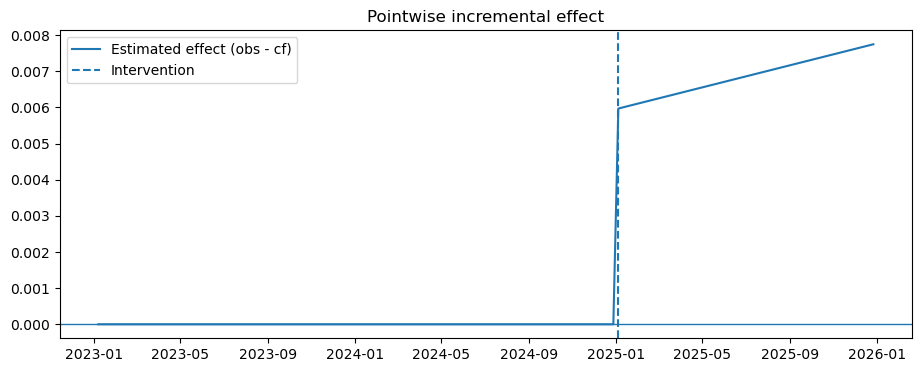

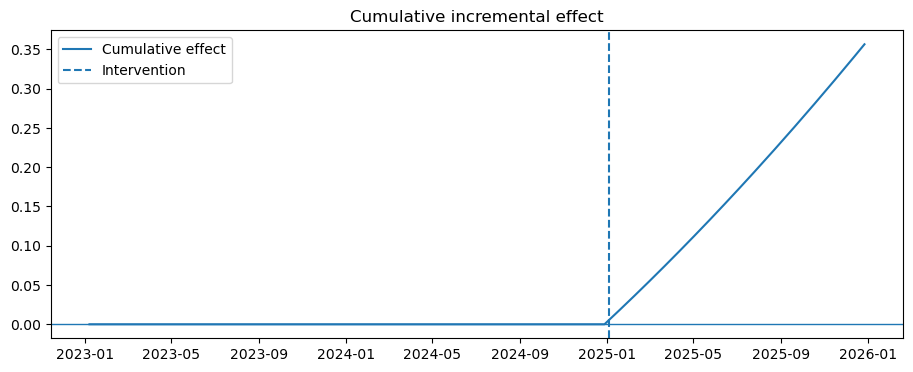

In [9]:
fig = plt.figure(figsize=(11, 4))
plt.plot(df_pred["week"], df_pred["effect"], label="Estimated effect (obs - cf)")
plt.axhline(0, linewidth=1)
plt.axvline(intervention_week, linestyle="--", label="Intervention")
plt.title("Pointwise incremental effect")
plt.legend()
plt.show()

df_pred["cum_effect"] = np.where(df_pred["week"] >= intervention_week, df_pred["effect"], 0).cumsum()

fig = plt.figure(figsize=(11, 4))
plt.plot(df_pred["week"], df_pred["cum_effect"], label="Cumulative effect")
plt.axhline(0, linewidth=1)
plt.axvline(intervention_week, linestyle="--", label="Intervention")
plt.title("Cumulative incremental effect")
plt.legend()
plt.show()


### What this chart shows

- **Pointwise effect** shows the estimated impact at each week after the intervention.
- **Cumulative effect** shows the running total over the post period.

Pointwise effects help answer **when** the impact appeared. Cumulative effects help answer **how much total impact** accumulated over the evaluation window.


## 6) Robustness: placebo intervention dates

A useful falsification test is to pretend the intervention happened **earlier in the pre-period**.

If the model starts finding large effects at placebo dates, confidence in the main result should go down.


In [10]:
def fit_its_and_get_avg_effect(d, intervention_date, horizon_weeks=26, hac_lags=6):
    d = d.copy()
    d["post"] = (d["week"] >= intervention_date).astype(int)
    t0_local = d.loc[d["week"] >= intervention_date, "t"].min()
    d["t_post"] = np.where(d["post"].eq(1), d["t"] - t0_local, 0)

    model = smf.ols("y ~ t + post + t_post + C(month) + mkt_index", data=d).fit(
        cov_type="HAC", cov_kwds={"maxlags": hac_lags}
    )

    d_pred = d.copy()
    d_cf = d_pred.copy()
    d_cf["post"] = 0
    d_cf["t_post"] = 0

    d_pred["y_hat_obs"] = model.predict(d_pred)
    d_pred["y_hat_cf"] = model.predict(d_cf)
    d_pred["effect"] = d_pred["y_hat_obs"] - d_pred["y_hat_cf"]

    post_window = d_pred.loc[d_pred["week"] >= intervention_date].head(horizon_weeks)
    return float(post_window["effect"].mean())

placebo_dates = [
    pd.Timestamp("2024-02-03"),
    pd.Timestamp("2024-05-04"),
    pd.Timestamp("2024-08-03"),
    intervention_week,
]

placebo_results = []
for dt in placebo_dates:
    avg_eff = fit_its_and_get_avg_effect(df, dt, horizon_weeks=26, hac_lags=6)
    placebo_results.append({"date": dt, "avg_effect_26w": avg_eff, "is_real_intervention": dt == intervention_week})

placebo_df = pd.DataFrame(placebo_results)
placebo_df


,date,avg_effect_26w,is_real_intervention
0,2024-02-03,-0.000721,False
1,2024-05-04,0.002147,False
2,2024-08-03,0.001165,False
3,2025-01-04,0.006404,True


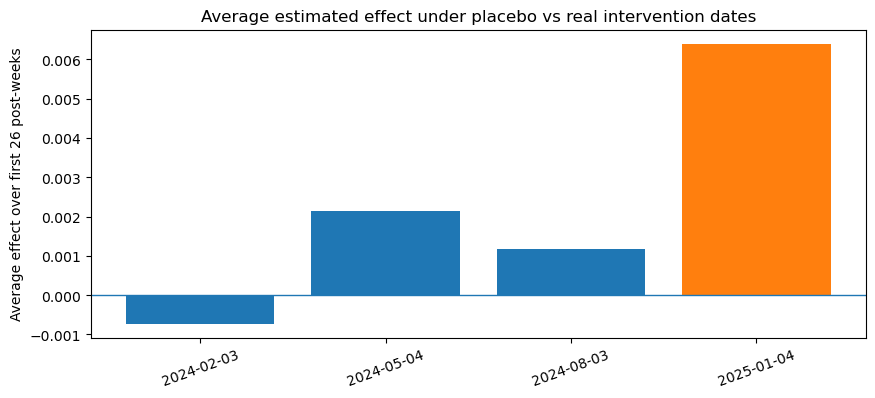

In [11]:
fig = plt.figure(figsize=(10, 4))
colors = ["tab:blue" if not x else "tab:orange" for x in placebo_df["is_real_intervention"]]
plt.bar(placebo_df["date"].dt.strftime("%Y-%m-%d"), placebo_df["avg_effect_26w"], color=colors)
plt.axhline(0, linewidth=1)
plt.title("Average estimated effect under placebo vs real intervention dates")
plt.ylabel("Average effect over first 26 post-weeks")
plt.xticks(rotation=20)
plt.show()


### What this chart shows

If the real intervention date produces a meaningfully larger estimated effect than placebo dates, that increases confidence that the model is capturing something specific to the intervention rather than a generic artifact of the time series.


## 7) Sensitivity checks

We now test whether the estimate changes materially under reasonable specification choices:

- different HAC lag choices
- different pre-period window lengths


In [12]:
# A) HAC lag sensitivity
lags_to_try = [2, 4, 6, 8, 12]
lag_results = []
for L in lags_to_try:
    eff = fit_its_and_get_avg_effect(df, intervention_week, horizon_weeks=26, hac_lags=L)
    lag_results.append((L, eff))

lag_df = pd.DataFrame(lag_results, columns=["hac_maxlags", "avg_effect_26w"])
lag_df


,hac_maxlags,avg_effect_26w
0,2,0.006404
1,4,0.006404
2,6,0.006404
3,8,0.006404
4,12,0.006404


In [13]:
# B) Pre-period window sensitivity
def prewindow_fit_effect(d, intervention_date, pre_weeks=52, hac_lags=6):
    d = d.copy()
    pre = d.loc[d["week"] < intervention_date].copy().tail(pre_weeks)
    post = d.loc[d["week"] >= intervention_date].copy()
    d2 = pd.concat([pre, post], ignore_index=True)

    # Rebuild time features relative to original intervention date
    t0_local = d2.loc[d2["week"] >= intervention_date, "t"].min()
    d2["post"] = (d2["week"] >= intervention_date).astype(int)
    d2["t_post"] = np.where(d2["post"].eq(1), d2["t"] - t0_local, 0)

    model = smf.ols("y ~ t + post + t_post + C(month) + mkt_index", data=d2).fit(
        cov_type="HAC", cov_kwds={"maxlags": hac_lags}
    )

    d2_pred = d2.copy()
    d2_cf = d2_pred.copy()
    d2_cf["post"] = 0
    d2_cf["t_post"] = 0
    d2_pred["y_hat_obs"] = model.predict(d2_pred)
    d2_pred["y_hat_cf"] = model.predict(d2_cf)
    d2_pred["effect"] = d2_pred["y_hat_obs"] - d2_pred["y_hat_cf"]

    post_window = d2_pred.loc[d2_pred["week"] >= intervention_date].head(26)
    return float(post_window["effect"].mean())

pre_windows = [52, 78, 104]
pre_results = []
for w in pre_windows:
    eff = prewindow_fit_effect(df, intervention_week, pre_weeks=w, hac_lags=6)
    pre_results.append((w, eff))

pre_df = pd.DataFrame(pre_results, columns=["pre_period_weeks", "avg_effect_26w"])
pre_df


,pre_period_weeks,avg_effect_26w
0,52,0.012271
1,78,0.005898
2,104,0.006404


## 8) Business interpretation

In this synthetic example, the ITS design estimates:

- an **immediate increase** in churn at the price change
- a **continued post-period effect** through the slope change
- a measurable **cumulative impact** over the evaluation window

The important business takeaway is not just the number. It is the comparison:

**What happened after the intervention vs what would likely have happened without it.**

That comparison is the core of causal measurement when a clean control group does not exist.


## Takeaways / How to adapt this to real work

- If **everyone is treated** by a global change, single-series ITS is often more credible than a naive before-and-after comparison.
- The core task is to build a **credible counterfactual** from the pre-period and compare it with the observed post-period path.
- Residual diagnostics, placebo dates, and sensitivity checks make the analysis more believable.
- If other major interventions overlap heavily with your intervention window, treat the estimate with caution.

## If you adapt this notebook

In real work, you would usually replace the synthetic data with:

- a real time series
- a clearly defined intervention date
- known seasonal features
- any important contemporaneous covariates
- a stronger discussion of threats to validity

This notebook is intended as a public, synthetic example of the workflow rather than a production-ready causal estimate.
